# Persona figures — KV-CACHED data source

Duplicate of `personaFigures/gen_figures.ipynb`, repointed to the
`--kv-cache` scoring path. Every figure below is regenerated from the
kv-cached reward-model scores instead of the original ones.

**Data flow.** This notebook reads the intermediate analysis CSVs
(`summary_correlations.csv`, `top_bottom_tokens.csv`,
`template_pair_correlations.csv`) from **`kv_analysis/output/`**, not
`persona_analysis/output/`. Those kv-cached intermediates are produced by:

```
python kv_analysis/analyze_personas_kv.py
```

which is a copy of `persona_analysis/analyze_personas.py` pointed at
`data/reward_model_scores_kv_cached/` and
`data/persona_reward_model_scores_kv_cached/`. **Run that script first**
if `kv_analysis/output/` is empty. Figures are written to
`kv_analysis/figures/`, leaving `personaFigures/output/` untouched.

Everything else (config, template selection, category groupings, plot
code) is identical to the original notebook, so figures are directly
comparable side by side.

# Generating Figures for Persona-Extended Analysis

## SETUP/CONFIG

In [1]:
# assignments 
BASELINE_TYPE = 'neutral' # 'neutral' (no prefix) or 'control' (person prefix)
RBO_P = 0.95 # 0.90, 0.95, 0.99 ->  lower p = quicker decay (more weighting on higher ranks)

# which prompt template to analyse. pick a friendly name on the left; it maps
# to the corresponding `template` value in the persona_analysis CSVs.
PROMPT_TEMPLATE = 'default greatest'  # see TEMPLATE_MAP keys for the options
TEMPLATE_MAP = {
    'default greatest':   'greatest_self_id',              # bare self-ID
    'what do you think':  'greatest_self_id_you_think',
    'what do I think':    'greatest_self_id_think',
    'what do people think':'greatest_self_id_people_think',
    'worst':              'worst_self_id',
}
TEMPLATE = TEMPLATE_MAP[PROMPT_TEMPLATE]

# category groupings
CATEGORY = {}
for p in ["a_black_person", "a_white_person", "an_asian_person"]:
    CATEGORY[p] = "race"
for p in ["a_woman", "a_man", "a_non_binary_person"]:
    CATEGORY[p] = "gender"
for p in ["a_black_woman", "a_black_man", "a_white_woman", "a_white_man"]:
    CATEGORY[p] = "intersectional"
for p in ["a_baby_boomer", "a_millennial", "a_member_of_generation_z"]:
    CATEGORY[p] = "age"
for p in ["a_person_with_add_or_adhd", "a_person_with_impaired_vision", "a_person_without_disabilities"]:
    CATEGORY[p] = "disability"
CATEGORY["a_person"] = "control"
for p in ["an_anglican", "an_atheist", "a_buddhist", "a_catholic", "a_copt", "a_hindu",
          "a_jehovah_s_witness", "a_jewish_person", "a_mormon", "an_orthodox_christian",
          "a_protestant", "a_satanist", "a_scientologist", "a_shia_muslim", "a_sikh", "a_sunni_muslim"]:
    CATEGORY[p] = "religion"
for p in ["an_anarchist", "a_centrist", "a_communist", "a_conservative", "a_democrat",
          "a_far_left_person", "a_far_right_person", "a_green_party_supporter", "an_islamist",
          "a_liberal", "a_libertarian", "a_nationalist", "a_republican", "a_social_democrat",
          "a_socialist", "a_zionist"]:
    CATEGORY[p] = "political"

CAT_COLOR = {
    "race": "#4C72B0", "gender": "#55A868", "intersectional": "#DD8452",
    "age": "#8172B2", "disability": "#937860", "control": "#8C8C8C",
    "religion": "#C44E52", "political": "#CCB974",
}

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# walk up until we find the repo root (marked by persona_analysis/), so this
# notebook works regardless of the kernel's working directory
ROOT = Path.cwd()
while not (ROOT / 'persona_analysis').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

# kv-cached analysis intermediates, produced by analyze_personas_kv.py
ANALYSIS_DIR = ROOT / 'kv_analysis' / 'output'
OUTPUT_DIR = ROOT / 'kv_analysis' / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def slugify(persona_col):
    return (
        persona_col.str.strip().str.lower()
        .str.replace(r'[^a-z0-9]+', '_', regex=True)
        .str.strip('_')
    )


corr = pd.read_csv(ANALYSIS_DIR / 'summary_correlations.csv')

# the selected prompt template (PROMPT_TEMPLATE -> TEMPLATE) vs. the persona's
# chosen baseline (BASELINE_TYPE), at the configured RBO fidelity (RBO_P)
corr = corr[
    (corr['template'] == TEMPLATE) &
    (corr['baseline_type'] == BASELINE_TYPE)
].copy()

corr['persona_slug'] = slugify(corr['persona'])
corr['category'] = corr['persona_slug'].map(CATEGORY)
corr['rbo'] = corr[f'rbo_p{RBO_P:.2f}']

# per-persona top-5/bottom-5 scoring tokens (Figure 2); same template/baseline
# filter as corr, so the two stay consistent with each other
tokens = pd.read_csv(ANALYSIS_DIR / 'top_bottom_tokens.csv')
tokens = tokens[
    (tokens['template'] == TEMPLATE) &
    (tokens['baseline_type'] == BASELINE_TYPE)
].copy()
tokens['persona_slug'] = slugify(tokens['persona'])
tokens['category'] = tokens['persona_slug'].map(CATEGORY)

corr.head()

,model,model_nickname,template,persona,persona_category,baseline_type,n_tokens,kendall_tau,kendall_p,spearman_rho,...,lm_kendall_tau,lm_kendall_p,lm_spearman_rho,lm_spearman_p,lm_rbo_p0.90,lm_rbo_p0.95,lm_rbo_p0.99,persona_slug,category,rbo
0,Ray2333/GRM-Llama3.2-3B-rewardmodel-ft,R-Lla-3B,greatest_self_id,a Black person,race,neutral,128250,0.727638,0.0,0.896941,...,0.459833,0.0,0.636518,0.0,0.475444,0.476008,0.465338,a_black_person,race,0.314810
10,Ray2333/GRM-Llama3.2-3B-rewardmodel-ft,R-Lla-3B,greatest_self_id,a white person,race,neutral,128250,0.725526,0.0,0.894530,...,0.587408,0.0,0.776648,0.0,0.641763,0.632290,0.607617,a_white_person,race,0.396968
20,Ray2333/GRM-Llama3.2-3B-rewardmodel-ft,R-Lla-3B,greatest_self_id,an Asian person,race,neutral,128250,0.737645,0.0,0.904521,...,0.579594,0.0,0.768882,0.0,0.532844,0.571883,0.597684,an_asian_person,race,0.438447
30,Ray2333/GRM-Llama3.2-3B-rewardmodel-ft,R-Lla-3B,greatest_self_id,a woman,gender,neutral,128250,0.764620,0.0,0.920693,...,0.592424,0.0,0.781589,0.0,0.632382,0.634808,0.610113,a_woman,gender,0.251530
40,Ray2333/GRM-Llama3.2-3B-rewardmodel-ft,R-Lla-3B,greatest_self_id,a man,gender,neutral,128250,0.801773,0.0,0.943135,...,0.701893,0.0,0.878104,0.0,0.700675,0.735815,0.744951,a_man,gender,0.385812


## FIGURE GENERATION

### (1) How do reward model token rankings vary by user persona (RM persona shifts)?

#### For each category (age, intersectionality, religion..), we want the average Kendall tau and RBO ±s.d. (to give a sense of the variability) for the default greatest prompt. 
A plot that summarizes this ^ would features panels: with the y axis on one panel tracking Kendall tau and on the other, RBO. on the x axis you want the different persona categories (i.e. age, gender...) and with lower alpha (i.e. high transparency), you should show each individual data point (e.g. boomer, gen z, etc.) and overlaid the mean and s.d. for each category 

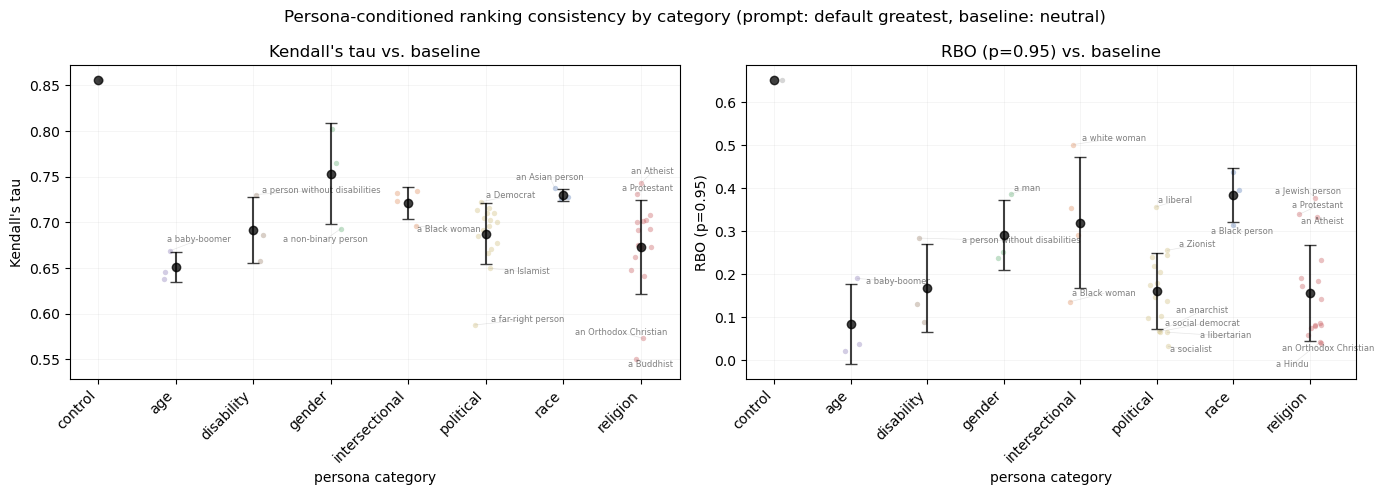

In [3]:
# FIGURE 1
from adjustText import adjust_text

metrics = [('kendall_tau', "Kendall's tau"), ('rbo', f'RBO (p={RBO_P})')]
categories = sorted(corr['category'].dropna().unique(), key=lambda c: (c != 'control', c))
rng = np.random.default_rng(0)

# a point counts as an outlier (gets labeled) if it's >1 s.d. from its
# category's mean; categories with too few points to have a meaningful s.d.
# (e.g. 'control', which has only one persona) are never labeled
OUTLIER_SD = 1.0

# margin between a label and anything it shouldn't overlap (other labels,
# points, whiskers): (x, y) multipliers on each bounding box before
# adjust_text checks for collisions -- 1.0 = no margin, bigger = more room
LABEL_MARGIN = (1.3, 1.5)

# opacity of the mean +- s.d. marker/error bar (1.0 = solid black)
MEAN_SD_ALPHA = 0.75

# opacity of the background gridlines (0 = off)
GRID_ALPHA = 0.15

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, ylabel) in zip(axes, metrics):
    # axis setup (x-axis 'category group', y-axis metric)
    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.set_xlabel('persona category')
    ax.set_ylabel(ylabel)
    ax.set_axisbelow(True)  # keep gridlines behind everything else drawn on this axes
    ax.grid(True, alpha=GRID_ALPHA, linewidth=0.6)

    summary = corr.groupby('category')[col].agg(['mean', 'std']).reindex(categories)
    texts, anchors = [], []
    # coordinates labels should steer clear of: every scatter dot, plus
    # samples along each category's mean+-s.d. whisker (so labels don't land
    # on top of a neighboring category's error bar either)
    avoid_x, avoid_y = [], []

    # low-transparency/small-dot individual datapoints, with outliers labeled
    for i, cat in enumerate(categories):
        sub = corr[corr['category'] == cat]
        vals = sub[col].to_numpy()
        jitter = rng.uniform(-0.15, 0.15, size=len(vals))
        xs = np.full(len(vals), i) + jitter
        ax.scatter(xs, vals, s=15, alpha=0.35,
                   color=CAT_COLOR.get(cat, '#333333'), linewidths=0, zorder=1)
        avoid_x.extend(xs)
        avoid_y.extend(vals)

        cat_mean, cat_std = summary.loc[cat, 'mean'], summary.loc[cat, 'std']
        if pd.notna(cat_std) and cat_std > 0:
            whisker_ys = np.linspace(cat_mean - cat_std, cat_mean + cat_std, 5)
            avoid_x.extend([i] * len(whisker_ys))
            avoid_y.extend(whisker_ys)
        else:
            avoid_x.append(i)
            avoid_y.append(cat_mean)

        is_outlier = (
            np.abs(vals - cat_mean) > OUTLIER_SD * cat_std
            if pd.notna(cat_std) and cat_std > 0 else np.zeros(len(vals), dtype=bool)
        )
        for x, y, persona in zip(xs[is_outlier], vals[is_outlier], sub['persona'].to_numpy()[is_outlier]):
            texts.append(ax.text(x, y, persona, fontsize=6, alpha=0.5))
            anchors.append((x, y))

    # mean and standard deviation for each category
    ax.errorbar(range(len(categories)), summary['mean'], yerr=summary['std'],
                fmt='o', color='black', ecolor='black', elinewidth=1.5,
                capsize=4, markersize=6, zorder=2, alpha=MEAN_SD_ALPHA)

    # repel overlapping outlier labels apart from each other, from every dot,
    # and from mean/s.d. whiskers (including neighboring categories'), then
    # always draw a connector back to the point (adjust_text only draws its
    # built-in arrow when a label actually moved, leaving un-moved labels
    # visually disconnected from their point otherwise)
    if texts:
        adjust_text(texts, x=avoid_x, y=avoid_y, ax=ax, expand=LABEL_MARGIN)
        for text, (ox, oy) in zip(texts, anchors):
            tx, ty = text.get_position()
            ax.plot([ox, tx], [oy, ty], color='gray', linewidth=0.5, alpha=0.2, zorder=1.5)

axes[0].set_title("Kendall's tau vs. baseline")
axes[1].set_title(f'RBO (p={RBO_P}) vs. baseline')
fig.suptitle(f"Persona-conditioned ranking consistency by category "
             f"(prompt: {PROMPT_TEMPLATE}, baseline: {BASELINE_TYPE})")
fig.tight_layout()

fig.savefig(OUTPUT_DIR / f'figure_1_tau_rbo_by_category_{TEMPLATE}.png', dpi=300, bbox_inches='tight')
plt.show()

#### Top and bottom personas in terms of consistency with the default prompt (in terms of RBO)
Select the bottom persona (in terms of RBO) for each category and create a table that presents the top 5 highest and lowest scoring tokens for each

In [4]:
# FIGURE 2
from IPython.display import display
import dataframe_image as dfi
from concurrent.futures import ThreadPoolExecutor


def export_table_png(styled, path):
    """dataframe_image's PNG export drives headless Chromium via Playwright's
    *sync* API, which refuses to run inside a thread that already has a
    running asyncio event loop -- which the Jupyter kernel's main thread
    always does. Running it in a plain worker thread sidesteps that (no
    running loop there), rather than trying to patch the kernel's loop."""
    with ThreadPoolExecutor(max_workers=1) as ex:
        ex.submit(dfi.export, styled, path, dpi=300).result()


def format_token_label(token_decoded):
    """Render whitespace visibly so whitespace-only/whitespace-padded tokens
    (common in BPE vocabularies) don't look blank or get silently collapsed
    when displayed in a table."""
    if pd.isna(token_decoded):
        return '<NA>'
    s = str(token_decoded)
    if s == '':
        return '<empty>'
    if s.strip(' ') == '':
        return '␣' * len(s)
    leading = len(s) - len(s.lstrip(' '))
    trailing = len(s) - len(s.rstrip(' '))
    core = s[leading:len(s) - trailing] if trailing else s[leading:]
    core = core.replace('\n', '\\n').replace('\t', '\\t').replace('\r', '\\r')
    return ('␣' * leading) + core + ('␣' * trailing)


# the "control" category has only one persona ("a person"), so there's no
# meaningful "worst of several" to pick -- skip it here
candidate_categories = [c for c in corr['category'].dropna().unique() if c != 'control']

# for each category, the persona whose ranking is *least* consistent with
# baseline (lowest RBO) under the selected prompt template
worst_idx = corr[corr['category'].isin(candidate_categories)].groupby('category')['rbo'].idxmin()
worst = corr.loc[worst_idx, ['category', 'persona', 'rbo']].set_index('category').sort_index()

for cat, row in worst.iterrows():
    persona = row['persona']
    sub = tokens[tokens['persona'] == persona]

    top5 = (
        sub[sub['group'] == 'top'].sort_values('rank_in_group')
        [['token_decoded', 'score', 'rank_diff']].reset_index(drop=True)
    )
    bottom5 = (
        sub[sub['group'] == 'bottom'].sort_values('rank_in_group')
        [['token_decoded', 'score', 'rank_diff']].reset_index(drop=True)
    )
    for df in (top5, bottom5):
        df['token_decoded'] = df['token_decoded'].map(format_token_label)
        df.index += 1

    table = pd.concat({'top 5': top5, 'bottom 5': bottom5}, names=['group', 'rank'])

    title = f"{cat}  |  least consistent persona: '{persona}'  (RBO={row['rbo']:.3f})"
    styled = (
        table.style
        .set_caption(title)
        .format({'score': '{:.2f}', 'rank_diff': '{:+.0f}'})
        .bar(subset=['score'], color='#4C72B0', align='mid')
    )

    print(title)
    display(styled)
    export_table_png(styled, OUTPUT_DIR / f'figure_2_top_bottom_tokens_{TEMPLATE}_{cat}.png')

age  |  least consistent persona: 'a millennial'  (RBO=0.021)


disability  |  least consistent persona: 'a person with impaired vision'  (RBO=0.089)


gender  |  least consistent persona: 'a non-binary person'  (RBO=0.237)


intersectional  |  least consistent persona: 'a Black woman'  (RBO=0.136)


political  |  least consistent persona: 'a socialist'  (RBO=0.032)


race  |  least consistent persona: 'a Black person'  (RBO=0.315)


religion  |  least consistent persona: 'an Orthodox Christian'  (RBO=0.040)


### (2) Do persona shifts in the RM relate to persona shifts in the base LLM?

Here, we want to summarize our log prob results.
A coarse analysis would report the correlation coefficient between RM RBO (/ kendall tau) and base model RBO for the default greatest prompt / control greatest prompt.

In [5]:
# (2) COARSE: how strongly does the RM's persona shift track the base LM's?
# One correlation coefficient per (baseline x metric): across the 49 personas,
# correlate the RM's consistency-with-baseline against the base LM's.
from scipy import stats
from IPython.display import display

RBO_COL, LM_RBO_COL = f'rbo_p{RBO_P:.2f}', f'lm_rbo_p{RBO_P:.2f}'
# (rm_col, lm_col, human-readable label) for each metric we compare
METRIC_PAIRS = [
    ('kendall_tau', 'lm_kendall_tau', "Kendall's tau"),
    (RBO_COL, LM_RBO_COL, f'RBO (p={RBO_P})'),
]

# re-load unfiltered by baseline so we can show 'neutral' (default greatest)
# and 'control' (control greatest) side by side, as the section asks; keep the
# selected TEMPLATE. lm_* columns are already present in this CSV.
c2 = pd.read_csv(ANALYSIS_DIR / 'summary_correlations.csv')
c2 = c2[c2['template'] == TEMPLATE].copy()
c2['persona_slug'] = slugify(c2['persona'])
c2['category'] = c2['persona_slug'].map(CATEGORY)

rows = []
for baseline in ['neutral', 'control']:
    b = c2[c2['baseline_type'] == baseline]
    for rm_col, lm_col, label in METRIC_PAIRS:
        pear = stats.pearsonr(b[lm_col], b[rm_col])
        spear = stats.spearmanr(b[lm_col], b[rm_col])
        rows.append({
            'baseline': baseline, 'metric': label, 'n_personas': len(b),
            'pearson_r': pear.statistic, 'pearson_p': pear.pvalue,
            'spearman_r': spear.statistic, 'spearman_p': spear.pvalue,
        })
coarse = pd.DataFrame(rows)

print(f"RM vs. base-LM persona shift  |  prompt: {PROMPT_TEMPLATE}")
display(
    coarse.style
    .format({'pearson_r': '{:.3f}', 'pearson_p': '{:.1e}',
             'spearman_r': '{:.3f}', 'spearman_p': '{:.1e}'})
    .hide(axis='index')
)
coarse.to_csv(OUTPUT_DIR / f'figure_3_rm_vs_lm_correlations_{TEMPLATE}.csv', index=False)

RM vs. base-LM persona shift  |  prompt: default greatest


baseline,metric,n_personas,pearson_r,pearson_p,spearman_r,spearman_p
neutral,Kendall's tau,49,0.740,1.2e-09,0.724,4.3e-09
neutral,RBO (p=0.95),49,0.693,3.4e-08,0.637,8.8e-07
control,Kendall's tau,49,0.837,6.5e-14,0.798,6.7e-12
control,RBO (p=0.95),49,0.730,2.6e-09,0.603,4.6e-06


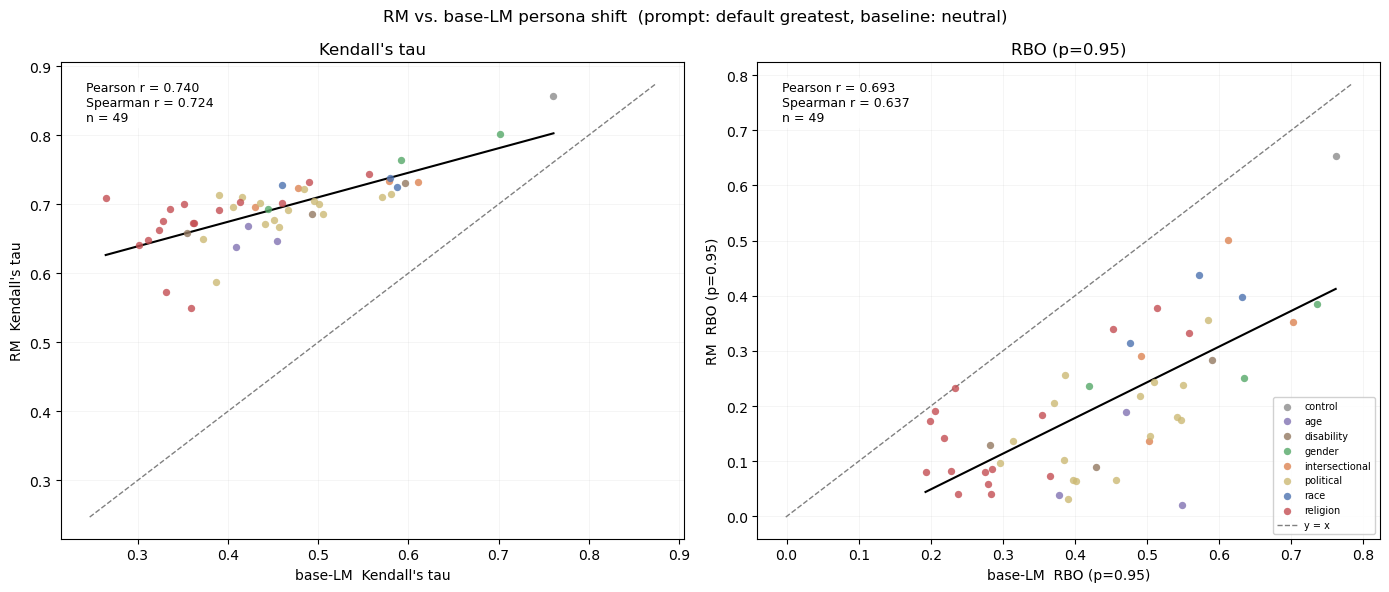

In [6]:
# FIGURE 3 -- the scatter behind the coarse correlation.
# One point per persona (colored by category): base-LM persona shift (x) vs.
# RM persona shift (y), for the selected TEMPLATE + BASELINE_TYPE. The dashed
# y=x line marks "RM shifts exactly as much as the base LM"; points below it
# are personas the RM shifts MORE than the base model does.
b = c2[c2['baseline_type'] == BASELINE_TYPE]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (rm_col, lm_col, label) in zip(axes, METRIC_PAIRS):
    x, y = b[lm_col].to_numpy(), b[rm_col].to_numpy()

    for cat in categories:
        sub = b[b['category'] == cat]
        if len(sub):
            ax.scatter(sub[lm_col], sub[rm_col], s=28, alpha=0.8,
                       color=CAT_COLOR.get(cat, '#333333'), linewidths=0,
                       label=cat, zorder=3)

    # y=x reference (shared data range across both axes)
    lo = min(x.min(), y.min()); hi = max(x.max(), y.max())
    pad = 0.03 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            color='gray', linestyle='--', linewidth=1, zorder=1, label='y = x')

    # OLS fit line + correlation annotation
    slope, intercept = np.polyfit(x, y, 1)
    xs_line = np.array([x.min(), x.max()])
    ax.plot(xs_line, slope * xs_line + intercept, color='black',
            linewidth=1.5, zorder=2)
    pear = stats.pearsonr(x, y); spear = stats.spearmanr(x, y)
    ax.text(0.04, 0.96,
            f"Pearson r = {pear.statistic:.3f}\nSpearman r = {spear.statistic:.3f}\nn = {len(b)}",
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, linewidth=0))

    ax.set_xlabel(f'base-LM  {label}')
    ax.set_ylabel(f'RM  {label}')
    ax.set_title(label)
    ax.set_axisbelow(True)
    ax.grid(True, alpha=0.15, linewidth=0.6)

axes[1].legend(fontsize=7, loc='lower right', framealpha=0.9)
fig.suptitle(f'RM vs. base-LM persona shift  '
             f'(prompt: {PROMPT_TEMPLATE}, baseline: {BASELINE_TYPE})')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f'figure_3_rm_vs_lm_scatter_{TEMPLATE}_{BASELINE_TYPE}.png',
            dpi=300, bbox_inches='tight')
plt.show()

#### Fine-grained: which personas does the *reward model* shift beyond the base LM?

The coarse correlation says RM and base-LM persona shifts move together, but a single `r` hides *where they diverge*. RBO is consistency-with-baseline (1 = identical ranking, 0 = disjoint), so **lower RBO = bigger shift**. For each persona we take

> `gap = base-LM RBO − RM RBO`

A **positive gap** means the RM's token ranking moved away from its baseline *more* than the base LM's did. Figure 4 ranks all personas by this gap (colored by category); Figure 3 is the scatter behind the coarse `r`, with the `y = x` line marking "RM shifts exactly as much as the base LM."

**⚠️ Interpret the gap relative to the control, not to zero.** The gap is positive for *every* persona — including the **control persona ("a person")**, which carries no identity content at all (gap ≈ +0.11). That baseline offset is a **measurement artifact, not amplification**: the base-LM metric is the *first next-token* distribution, which is grammar-dominated (its top-ranked tokens are sentence-openers like `The`/`That`/`What` and barely move across personas → high LM RBO), whereas the RM scores a token as a *whole response*, which is semantics-dominated (its top tokens are content words that swing hard across personas → low RM RBO). Because RBO is top-weighted, it magnifies exactly this difference, regardless of identity. The control persona's gap therefore marks the **"any-prefix floor"** — drawn as the **crimson line** in Figure 4. **Only a persona's distance to the *right* of that line reflects identity-specific amplification**; bars at or to the left of it sit within the artifact floor. The walk-through below accordingly reports each persona's gap *beyond the control floor* (`gap_vs_control`), not the raw gap.

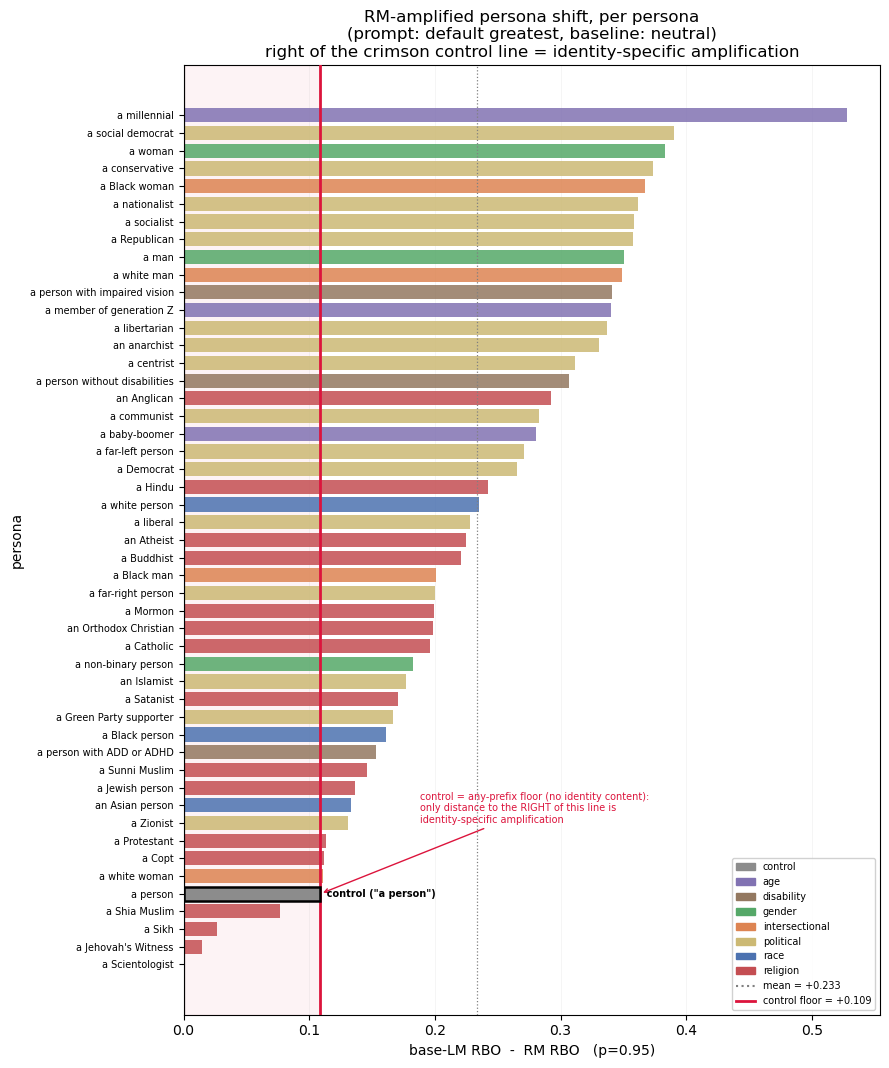

Control ("a person") floor gap = +0.109 (artifact baseline; identity-specific amplification is measured beyond this)

Most identity-amplified (largest gap BEYOND the control floor):
          persona       category      gap  gap_vs_control
     a millennial            age 0.527640        0.418760
a social democrat      political 0.390184        0.281304
          a woman         gender 0.383279        0.274399
   a conservative      political 0.373168        0.264287
    a Black woman intersectional 0.366809        0.257929

At or below the control floor (raw gap positive, but NOT identity-specific):
            persona category      gap  gap_vs_control
    a Scientologist religion 0.000458       -0.108423
a Jehovah's Witness religion 0.014559       -0.094321
             a Sikh religion 0.026287       -0.082593
      a Shia Muslim religion 0.076668       -0.032213
           a person  control 0.108880        0.000000


In [7]:
# FIGURE 4 (fine-grained) -- where does the RM shift MORE than the base LM?
# For each persona: gap = (base-LM RBO) - (RM RBO). Because RBO is
# consistency-with-baseline, a positive gap means the RM's ranking moved away
# from baseline more than the base LM's did -> an "RM-amplified" persona shift.
#
# CAVEAT (see markdown above): the gap is positive for EVERY persona, INCLUDING
# the control ("a person"), which carries no identity content. That offset is a
# measurement artifact, not amplification -- the base-LM metric is the first
# next-token distribution (grammar-dominated, so its top ranks barely move),
# while the RM scores a token as a whole response (semantics-dominated, so its
# top ranks move a lot); top-weighted RBO magnifies the difference regardless of
# identity. The control persona's gap is therefore the "any-prefix floor"
# (crimson line): only a persona's distance to the RIGHT of it is identity-specific.
b = c2[c2['baseline_type'] == BASELINE_TYPE].copy()
b['gap'] = b[LM_RBO_COL] - b[RBO_COL]
b = b.sort_values('gap').reset_index(drop=True)

gap_mean, gap_std = b['gap'].mean(), b['gap'].std()

# the control persona's gap = any-prefix floor (crimson reference line below)
ctrl_pos = b.index[b['category'] == 'control']
control_gap = float(b.loc[ctrl_pos[0], 'gap']) if len(ctrl_pos) else None

fig, ax = plt.subplots(figsize=(9, max(6, 0.22 * len(b))))
ypos = np.arange(len(b))
colors = [CAT_COLOR.get(c, '#333333') for c in b['category']]
ax.barh(ypos, b['gap'], color=colors, alpha=0.85, zorder=2)

ax.set_yticks(ypos)
ax.set_yticklabels(b['persona'], fontsize=7)
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(gap_mean, color='gray', linestyle=':', linewidth=0.9,
           label=f'mean gap = {gap_mean:+.3f}')

# --- control persona as the interpretive baseline (Recommendation 2) ---
if control_gap is not None:
    k = int(ctrl_pos[0])
    # shade the region at/below the floor -- raw gap is positive here but it is
    # within the any-prefix artifact, not identity-specific amplification
    ax.axvspan(0, control_gap, color='crimson', alpha=0.05, zorder=0)
    # outline the control bar so it stands out among the category-colored bars
    ax.barh(k, control_gap, color=CAT_COLOR.get('control', '#333333'),
            edgecolor='black', linewidth=1.8, zorder=4)
    ax.text(control_gap, k, '  control ("a person")', va='center', ha='left',
            fontsize=7, fontweight='bold', color='black', zorder=5)
    # crimson floor line: the gap explained by ANY prefix, with no identity content
    ax.axvline(control_gap, color='crimson', linewidth=2, zorder=3)
    ax.annotate(
        'control = any-prefix floor (no identity content):\n'
        'only distance to the RIGHT of this line is\n'
        'identity-specific amplification',
        xy=(control_gap, k),
        xytext=(0.34, 0.20), textcoords='axes fraction',
        fontsize=7, color='crimson', va='bottom', ha='left',
        arrowprops=dict(arrowstyle='->', color='crimson', linewidth=1))

ax.set_xlabel(f'base-LM RBO  -  RM RBO   (p={RBO_P})')
ax.set_ylabel('persona')
ax.set_title(f'RM-amplified persona shift, per persona\n'
             f'(prompt: {PROMPT_TEMPLATE}, baseline: {BASELINE_TYPE})\n'
             f'right of the crimson control line = identity-specific amplification')
ax.set_axisbelow(True)
ax.grid(True, axis='x', alpha=0.15, linewidth=0.6)

# category legend (only categories actually present), plus the two reference lines
from matplotlib.patches import Patch
present = [c for c in categories if c in set(b['category'])]
handles = [Patch(color=CAT_COLOR.get(c, '#333333'), label=c) for c in present]
handles.append(plt.Line2D([0], [0], color='gray', linestyle=':', label=f'mean = {gap_mean:+.3f}'))
if control_gap is not None:
    handles.append(plt.Line2D([0], [0], color='crimson', linewidth=2,
                              label=f'control floor = {control_gap:+.3f}'))
ax.legend(handles=handles, fontsize=7, loc='lower right', framealpha=0.9)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / f'figure_4_rm_amplified_shift_{TEMPLATE}_{BASELINE_TYPE}.png',
            dpi=300, bbox_inches='tight')
plt.show()

# walk-through: report gaps RELATIVE to the control floor, not just the raw gap
if control_gap is not None:
    b['gap_vs_control'] = b['gap'] - control_gap
    print(f'Control ("a person") floor gap = {control_gap:+.3f} '
          f'(artifact baseline; identity-specific amplification is measured beyond this)')
    print('\nMost identity-amplified (largest gap BEYOND the control floor):')
    print(b.nlargest(5, 'gap_vs_control')[['persona', 'category', 'gap', 'gap_vs_control']].to_string(index=False))
    print('\nAt or below the control floor (raw gap positive, but NOT identity-specific):')
    print(b.nsmallest(5, 'gap_vs_control')[['persona', 'category', 'gap', 'gap_vs_control']].to_string(index=False))
else:
    print('Most RM-amplified (RM shifts far more than base LM):')
    print(b.nlargest(5, 'gap')[['persona', 'category', LM_RBO_COL, RBO_COL, 'gap']].to_string(index=False))
    print('\nLeast (RM tracks or shifts less than base LM):')
    print(b.nsmallest(5, 'gap')[['persona', 'category', LM_RBO_COL, RBO_COL, 'gap']].to_string(index=False))

(Image from Dashboard)
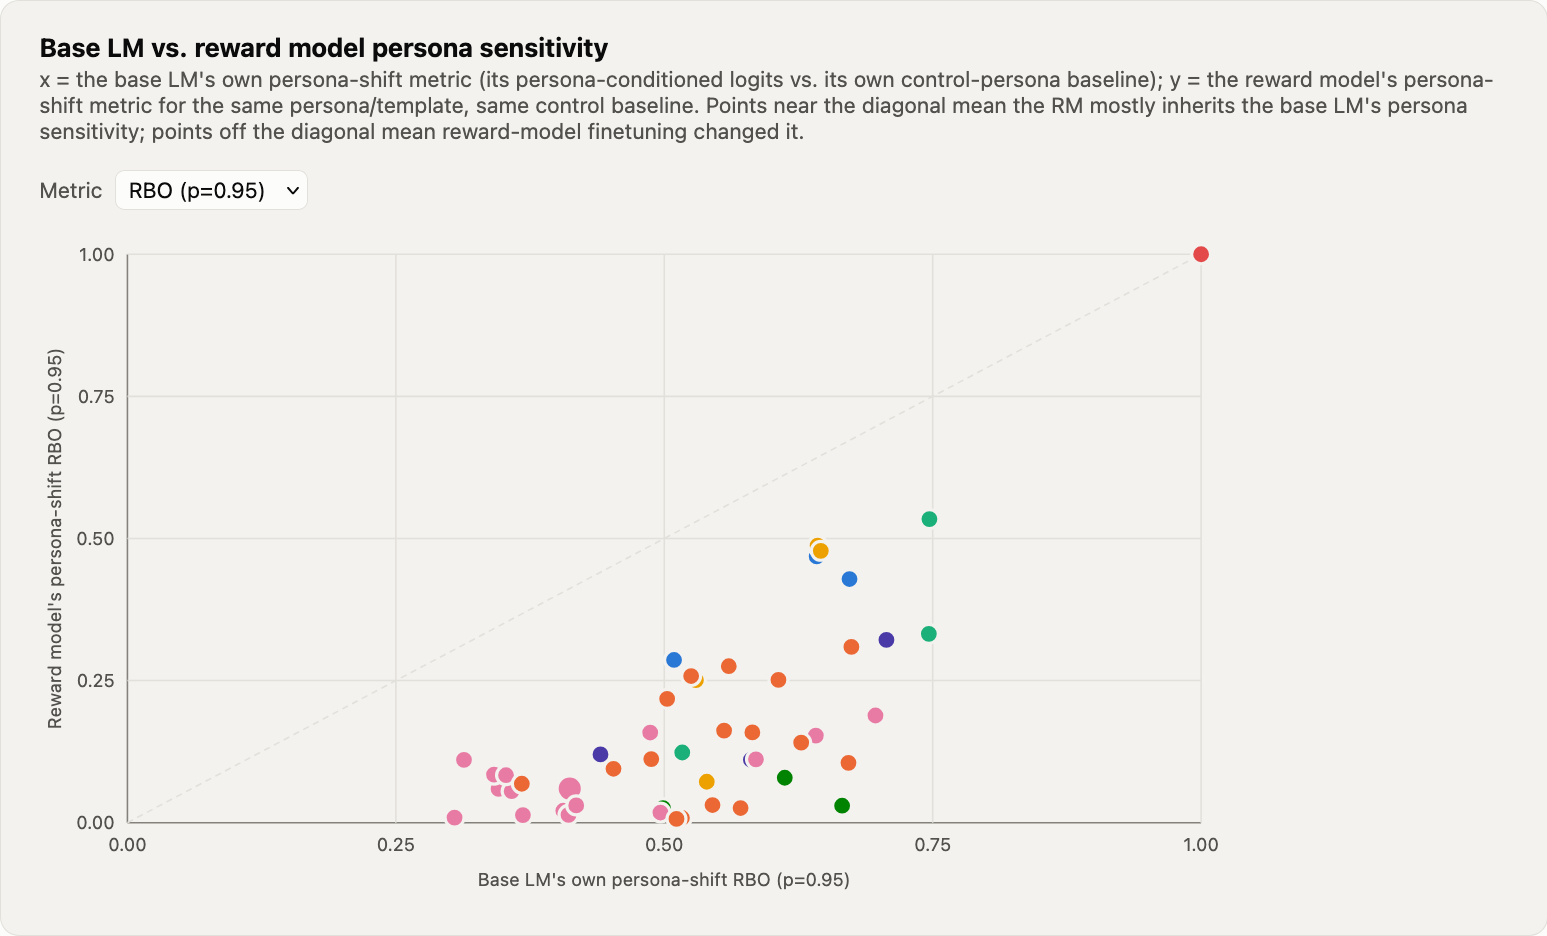

### (3) How does prompt valence (positive vs negative valence) affect RM persona shifts?

Pitting the RM persona shift (RBO, kendall tau on separate panels) in the default greatest (x axis) vs default worst prompt (y axis) against one another on a scatter plot

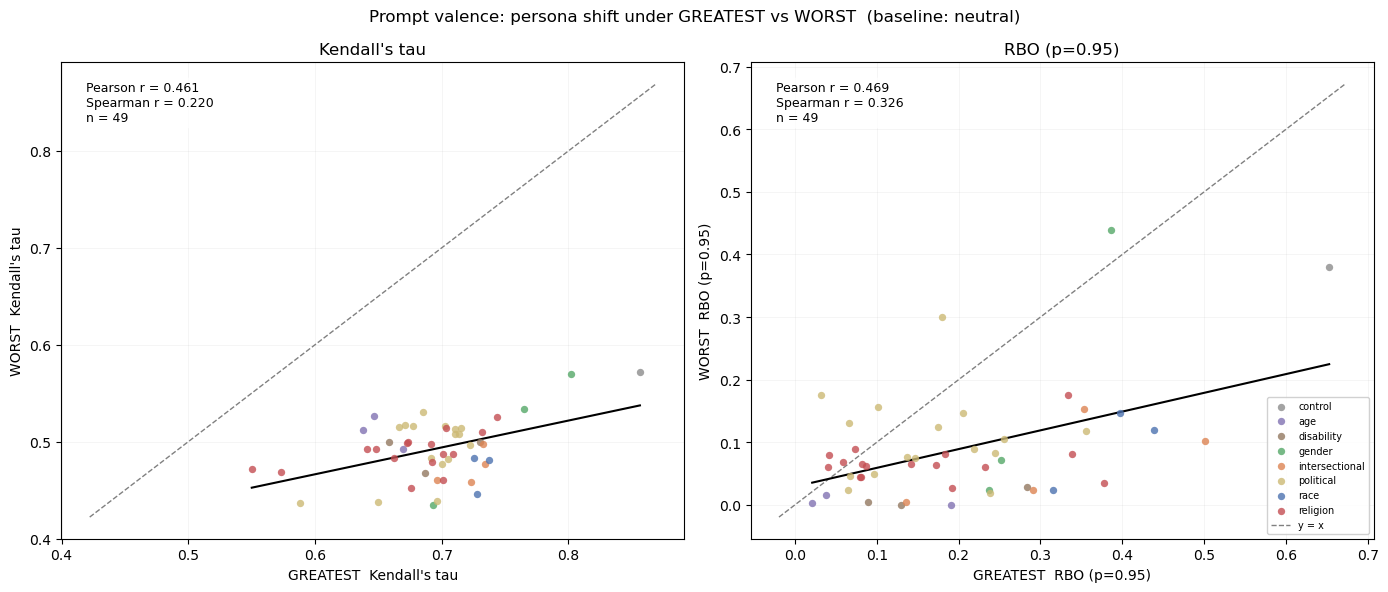

In [8]:
# FIGURE 5 (section 3) -- prompt valence.
# Does a persona that shifts the RM under the "greatest" framing also shift it
# under "worst"? One point per persona: persona-shift under default GREATEST (x)
# vs default WORST (y), where shift = consistency-with-baseline (lower = bigger
# shift). Separate panels for Kendall's tau and RBO; selected BASELINE_TYPE.
val = pd.read_csv(ANALYSIS_DIR / 'summary_correlations.csv')
val = val[val['baseline_type'] == BASELINE_TYPE].copy()
val['persona_slug'] = slugify(val['persona'])
val['category'] = val['persona_slug'].map(CATEGORY)

VAL_METRICS = [('kendall_tau', "Kendall's tau"), (f'rbo_p{RBO_P:.2f}', f'RBO (p={RBO_P})')]
greatest = val[val['template'] == 'greatest_self_id']
worst    = val[val['template'] == 'worst_self_id']
cats_present = sorted(val['category'].dropna().unique(), key=lambda c: (c != 'control', c))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (col, label) in zip(axes, VAL_METRICS):
    m = greatest[['persona', 'category', col]].merge(
        worst[['persona', col]], on='persona', suffixes=('_greatest', '_worst'))
    xg, yw = m[f'{col}_greatest'].to_numpy(), m[f'{col}_worst'].to_numpy()

    for cat in cats_present:
        s = m[m['category'] == cat]
        if len(s):
            ax.scatter(s[f'{col}_greatest'], s[f'{col}_worst'], s=28, alpha=0.8,
                       color=CAT_COLOR.get(cat, '#333333'), linewidths=0, label=cat, zorder=3)

    lo = min(xg.min(), yw.min()); hi = max(xg.max(), yw.max()); pad = 0.03 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            color='gray', linestyle='--', linewidth=1, zorder=1, label='y = x')
    slope, intercept = np.polyfit(xg, yw, 1); xs_line = np.array([xg.min(), xg.max()])
    ax.plot(xs_line, slope * xs_line + intercept, color='black', linewidth=1.5, zorder=2)

    pear = stats.pearsonr(xg, yw); spear = stats.spearmanr(xg, yw)
    ax.text(0.04, 0.96,
            f"Pearson r = {pear.statistic:.3f}\nSpearman r = {spear.statistic:.3f}\nn = {len(m)}",
            transform=ax.transAxes, va='top', ha='left', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, linewidth=0))

    ax.set_xlabel(f'GREATEST  {label}'); ax.set_ylabel(f'WORST  {label}')
    ax.set_title(label); ax.set_axisbelow(True); ax.grid(True, alpha=0.15, linewidth=0.6)

axes[1].legend(fontsize=7, loc='lower right', framealpha=0.9)
fig.suptitle(f'Prompt valence: persona shift under GREATEST vs WORST  (baseline: {BASELINE_TYPE})')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f'figure_5_valence_greatest_vs_worst_{BASELINE_TYPE}.png',
            dpi=300, bbox_inches='tight')
plt.show()

Correlation coefficient to give us a quantitative effect size.

In [9]:
# (3) quantitative effect size: correlation between GREATEST persona-shift and
# WORST persona-shift across the 49 personas, for both metrics and both
# baselines (default 'neutral' greatest vs 'control' greatest).
allc = pd.read_csv(ANALYSIS_DIR / 'summary_correlations.csv')
rows = []
for baseline in ['neutral', 'control']:
    d = allc[allc['baseline_type'] == baseline]
    g = d[d['template'] == 'greatest_self_id']
    w = d[d['template'] == 'worst_self_id']
    for col, label in VAL_METRICS:
        m = g[['persona', col]].merge(w[['persona', col]], on='persona', suffixes=('_g', '_w'))
        pear = stats.pearsonr(m[f'{col}_g'], m[f'{col}_w'])
        spear = stats.spearmanr(m[f'{col}_g'], m[f'{col}_w'])
        rows.append({
            'baseline': baseline, 'metric': label, 'n_personas': len(m),
            'pearson_r': pear.statistic, 'pearson_p': pear.pvalue,
            'spearman_r': spear.statistic, 'spearman_p': spear.pvalue,
        })
valence_corr = pd.DataFrame(rows)

print('GREATEST vs WORST persona-shift correlation (effect size)')
display(
    valence_corr.style
    .format({'pearson_r': '{:.3f}', 'pearson_p': '{:.1e}',
             'spearman_r': '{:.3f}', 'spearman_p': '{:.1e}'})
    .hide(axis='index')
)
valence_corr.to_csv(OUTPUT_DIR / 'figure_5_valence_correlations.csv', index=False)

GREATEST vs WORST persona-shift correlation (effect size)


baseline,metric,n_personas,pearson_r,pearson_p,spearman_r,spearman_p
neutral,Kendall's tau,49,0.461,8.6e-04,0.220,1.3e-01
neutral,RBO (p=0.95),49,0.469,6.8e-04,0.326,2.2e-02
control,Kendall's tau,49,0.831,1.4e-13,0.641,6.9e-07
control,RBO (p=0.95),49,0.774,7.1e-11,0.470,6.5e-04


### (4) How does the prompt agency framing (what do i vs you think) affect RM persona shifts?

Summarizing my results for 'what do i / you /people think' against the default prompt: reports the average correlation coefficient of RBO (and kendall tau) for each persona category between the default prompt and each of the  'what do i / you /people think' (±s.d.);

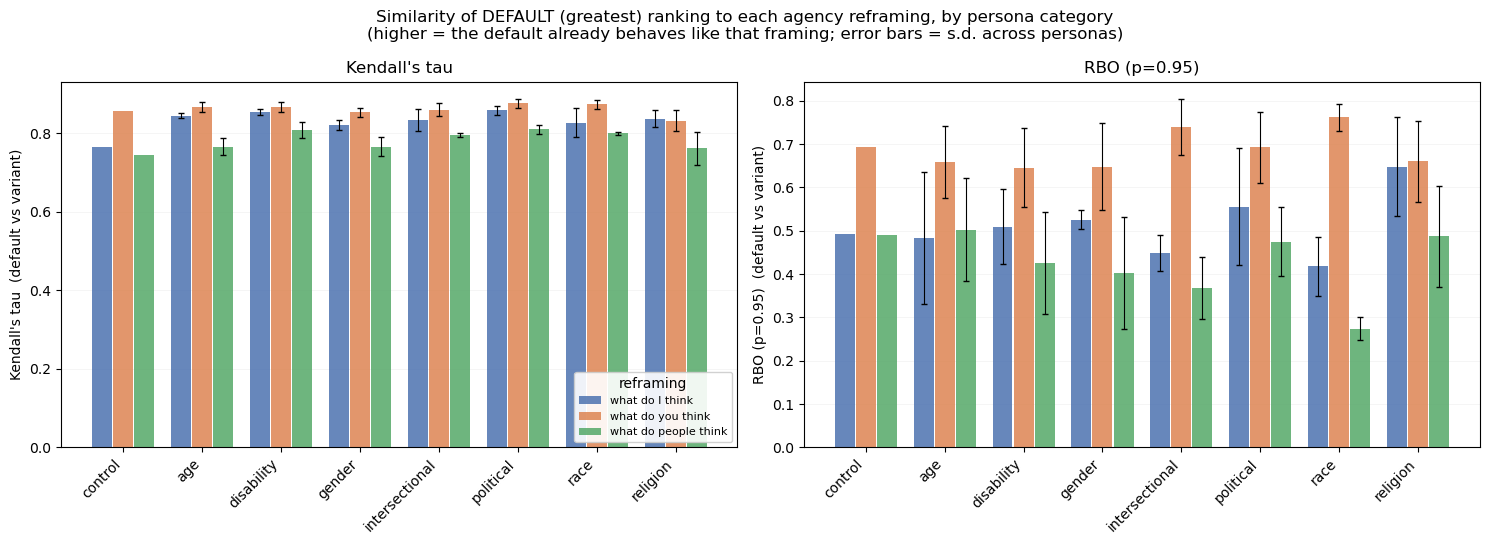

In [10]:
# FIGURE 6 (section 4) -- agency framing.
# template_pair_correlations.csv gives, per persona, how similar the RM's ranking
# under the DEFAULT prompt (greatest_self_id) is to each reframed variant. The
# rbo/tau values ARE rank-correlations between the two rankings, so high = the
# default and that framing produce near-identical persona rankings.
# Here: per persona category, the mean (+- s.d. across personas) similarity of
# the default prompt to each of the three "think" reframings.
tpc = pd.read_csv(ANALYSIS_DIR / 'template_pair_correlations.csv')
tpc['persona_slug'] = slugify(tpc['persona'])
tpc['category'] = tpc['persona_slug'].map(CATEGORY)

DEFAULT_TPL = 'greatest_self_id'
VARIANTS = [   # (template value, friendly label)  -- order = weakest->strongest agency framing
    ('greatest_self_id_think',        'what do I think'),
    ('greatest_self_id_you_think',    'what do you think'),
    ('greatest_self_id_people_think', 'what do people think'),
]
FRAME_METRICS = [('kendall_tau', "Kendall's tau"), (f'rbo_p{RBO_P:.2f}', f'RBO (p={RBO_P})')]
VARIANT_COLOR = {'what do I think': '#4C72B0', 'what do you think': '#DD8452',
                 'what do people think': '#55A868'}

# default-vs-variant rows only (template_a is always the default here)
dv = tpc[(tpc['template_a'] == DEFAULT_TPL) &
         (tpc['template_b'].isin([v for v, _ in VARIANTS]))].copy()
dv['variant'] = dv['template_b'].map(dict(VARIANTS))

frame_cats = sorted(dv['category'].dropna().unique(), key=lambda c: (c != 'control', c))
variant_labels = [lab for _, lab in VARIANTS]

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
width = 0.8 / len(variant_labels)
for ax, (col, label) in zip(axes, FRAME_METRICS):
    g = dv.groupby(['category', 'variant'])[col].agg(['mean', 'std'])
    xbase = np.arange(len(frame_cats))
    for j, vlab in enumerate(variant_labels):
        sub = g.xs(vlab, level='variant').reindex(frame_cats)
        offset = (j - (len(variant_labels) - 1) / 2) * width
        ax.bar(xbase + offset, sub['mean'], width * 0.95, yerr=sub['std'], capsize=2,
               color=VARIANT_COLOR[vlab], alpha=0.85, label=vlab,
               error_kw=dict(elinewidth=0.8))
    ax.set_xticks(xbase); ax.set_xticklabels(frame_cats, rotation=45, ha='right')
    ax.set_ylabel(f'{label}  (default vs variant)'); ax.set_title(label)
    ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=0.15, linewidth=0.6)

axes[0].legend(fontsize=8, title='reframing', loc='lower right', framealpha=0.9)
fig.suptitle('Similarity of DEFAULT (greatest) ranking to each agency reframing, by persona category\n'
             '(higher = the default already behaves like that framing; error bars = s.d. across personas)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_6_framing_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

Summarizing this across persona categories -- given the unequal sample sizes across categories, we do this by taking the mean of our aggregate measures from the previous visualisation.

In [11]:
# (4) summarize across categories. Categories have very unequal n (religion=16
# vs age=3), so we DON'T pool personas -- we take each category's mean (the bars
# in Figure 6) and average THOSE, giving every category equal weight. Result:
# one similarity-to-default number per variant/metric, +- s.d. across categories.
per_cat_means = {}   # metric_col -> DataFrame[category x variant] of means (reused by Figure 7)
summary_rows = []
for col, label in FRAME_METRICS:
    cat_means = (dv.groupby(['category', 'variant'])[col].mean()
                   .unstack('variant').reindex(index=frame_cats, columns=variant_labels))
    per_cat_means[col] = cat_means
    for vlab in variant_labels:
        vals = cat_means[vlab].dropna()
        summary_rows.append({
            'metric': label, 'variant': vlab, 'n_categories': len(vals),
            'mean_of_cat_means': vals.mean(), 'sd_across_cats': vals.std(),
        })
frame_summary = pd.DataFrame(summary_rows)

print('DEFAULT-vs-variant similarity, averaged over categories (equal weight per category)')
display(
    frame_summary.style
    .format({'mean_of_cat_means': '{:.3f}', 'sd_across_cats': '{:.3f}'})
    .hide(axis='index')
)
frame_summary.to_csv(OUTPUT_DIR / 'figure_7_framing_summary.csv', index=False)

DEFAULT-vs-variant similarity, averaged over categories (equal weight per category)


metric,variant,n_categories,mean_of_cat_means,sd_across_cats
Kendall's tau,what do I think,8,0.830,0.030
Kendall's tau,what do you think,8,0.861,0.014
Kendall's tau,what do people think,8,0.782,0.025
RBO (p=0.95),what do I think,8,0.510,0.071
RBO (p=0.95),what do you think,8,0.687,0.043
RBO (p=0.95),what do people think,8,0.428,0.079


Visualising this summary data (as in (1)): ultimately, we want to know which question formulation is our default prompt tapping into?

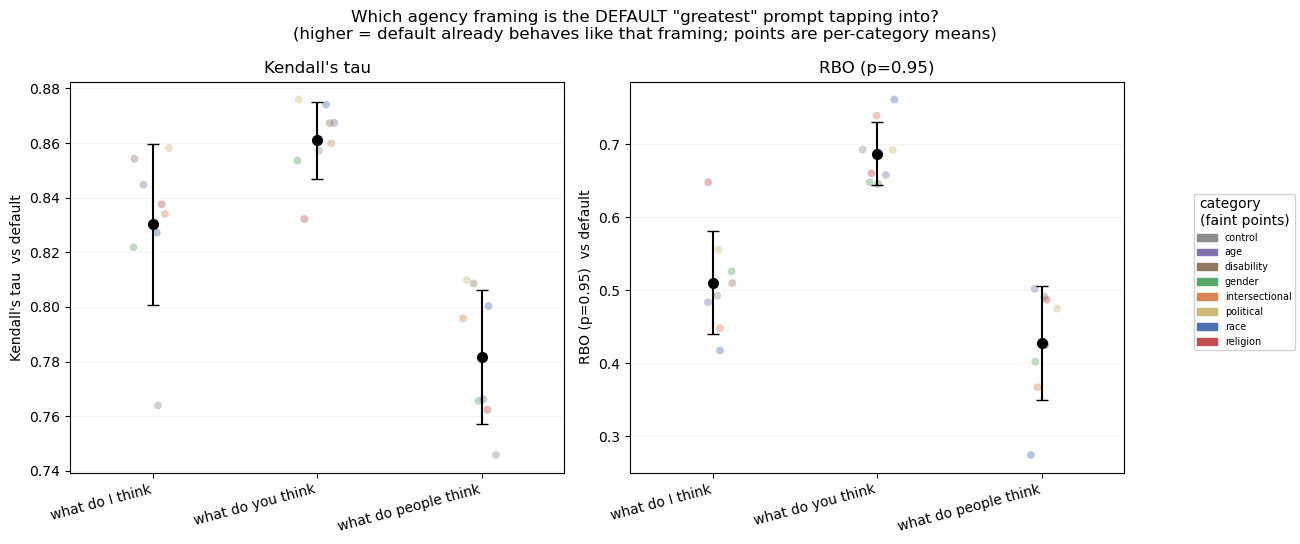

In [12]:
# FIGURE 7 (section 4, styled as Figure 1) -- which reframing is the DEFAULT
# prompt tapping into? x = the three agency framings; faint points = each
# category's similarity-to-default; black marker = mean over categories +- s.d.
# The framing with the HIGHEST similarity is the one the bare "greatest" prompt
# already behaves most like.
from matplotlib.patches import Patch
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
xpos = np.arange(len(variant_labels))
for ax, (col, label) in zip(axes, FRAME_METRICS):
    cat_means = per_cat_means[col]   # rows = category, cols = variant
    for j, vlab in enumerate(variant_labels):
        vals = cat_means[vlab].dropna()
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        colors = [CAT_COLOR.get(c, '#333333') for c in vals.index]
        ax.scatter(np.full(len(vals), j) + jitter, vals.to_numpy(), s=32, alpha=0.4,
                   color=colors, linewidths=0, zorder=1)
    means = [cat_means[v].mean() for v in variant_labels]
    sds   = [cat_means[v].std()  for v in variant_labels]
    ax.errorbar(xpos, means, yerr=sds, fmt='o', color='black', ecolor='black',
                elinewidth=1.5, capsize=4, markersize=7, zorder=2)
    ax.set_xticks(xpos); ax.set_xticklabels(variant_labels, rotation=15, ha='right')
    ax.set_xlim(-0.5, len(variant_labels) - 0.5)
    ax.set_ylabel(f'{label}  vs default'); ax.set_title(label)
    ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=0.15, linewidth=0.6)

fig.legend(handles=[Patch(color=CAT_COLOR.get(c, '#333333'), label=c) for c in frame_cats],
           fontsize=7, loc='center right', framealpha=0.9, title='category\n(faint points)')
fig.suptitle('Which agency framing is the DEFAULT "greatest" prompt tapping into?\n'
             '(higher = default already behaves like that framing; points are per-category means)')
fig.tight_layout(rect=[0, 0, 0.88, 1])
fig.savefig(OUTPUT_DIR / 'figure_7_framing_summary.png', dpi=300, bbox_inches='tight')
plt.show()

#### (4b) The other way: correlating persona-shifts *across* personas

(4a) measured similarity **per persona** — the RBO/τ between the default ranking and the variant ranking for that same persona, then averaged. This asks a different question: **across personas**, does the variant *reorder* who gets shifted the same way the default does? For each persona we take its shift-vs-baseline under the default prompt and under a variant (from `summary_correlations.csv`), then compute the Pearson `r` between those two vectors — within each category (Figure 6b), and pooled over all 49 personas (red dashes in Figure 7b).

The two views answer complementary things: 4a is *"does the framing leave each persona's ranking intact?"*; 4b is *"does the framing preserve the rank-ordering of which personas are most affected?"* Watch the small-n categories (age/gender/race/disability have only 3 personas) — their per-category `r`, **especially for Kendall's τ**, is very unstable, which is exactly why the pooled `r` is the more trustworthy read here.

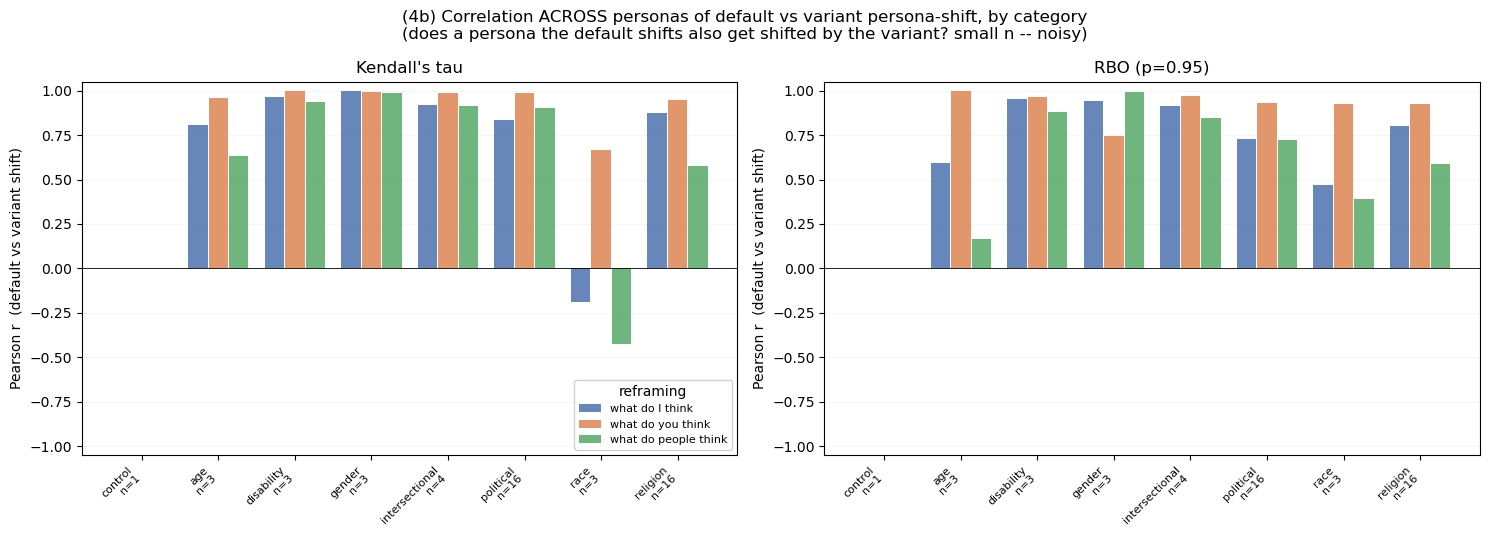

In [13]:
# FIGURE 6b (section 4, "the other way") -- instead of 4a's per-persona ranking
# similarity, correlate ACROSS personas: within each category, does a persona
# that shifts a lot under the DEFAULT prompt also shift a lot under the variant?
# Pearson r of default persona-shift vs variant persona-shift (from
# summary_correlations, selected BASELINE_TYPE). NOTE: most categories have only
# n=3 personas, so these r's are very noisy -- especially Kendall's tau, whose
# per-category spread is tiny. Reuses VARIANTS / FRAME_METRICS / frame_cats etc.
sc = pd.read_csv(ANALYSIS_DIR / 'summary_correlations.csv')
sc = sc[sc['baseline_type'] == BASELINE_TYPE].copy()
sc['category'] = slugify(sc['persona']).map(CATEGORY)
n_by_cat = sc[sc['template'] == DEFAULT_TPL].groupby('category').size()


def _paired(col, variant_tpl, category=None):
    """Personas' default-prompt shift joined to their variant-prompt shift."""
    d0 = sc[sc['template'] == DEFAULT_TPL]
    dv_ = sc[sc['template'] == variant_tpl]
    if category is not None:
        d0 = d0[d0['category'] == category]; dv_ = dv_[dv_['category'] == category]
    return d0[['persona', col]].merge(dv_[['persona', col]], on='persona', suffixes=('_def', '_var'))


def _pearson(m, col):
    a, b = m[f'{col}_def'], m[f'{col}_var']
    if len(m) >= 3 and a.std() > 0 and b.std() > 0:
        return stats.pearsonr(a, b).statistic
    return np.nan  # undefined for control (n=1) or a degenerate column


# long table of per-category r's (reused by the 4b summary cell)
rec = []
for col, label in FRAME_METRICS:
    for vt, vlab in VARIANTS:
        for cat in frame_cats:
            m = _paired(col, vt, cat)
            rec.append({'metric_col': col, 'metric': label, 'variant': vlab,
                        'category': cat, 'n': len(m), 'r': _pearson(m, col)})
frame_corr_percat = pd.DataFrame(rec)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
width = 0.8 / len(variant_labels)
xtick_labels = [f"{c}\nn={int(n_by_cat.get(c, 0))}" for c in frame_cats]
for ax, (col, label) in zip(axes, FRAME_METRICS):
    sub_m = frame_corr_percat[frame_corr_percat['metric_col'] == col]
    xbase = np.arange(len(frame_cats))
    for j, vlab in enumerate(variant_labels):
        s = sub_m[sub_m['variant'] == vlab].set_index('category').reindex(frame_cats)
        offset = (j - (len(variant_labels) - 1) / 2) * width
        ax.bar(xbase + offset, s['r'].fillna(0), width * 0.95,
               color=VARIANT_COLOR[vlab], alpha=0.85, label=vlab)
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(xbase); ax.set_xticklabels(xtick_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel('Pearson r  (default vs variant shift)'); ax.set_title(label)
    ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=0.15, linewidth=0.6)

axes[0].legend(fontsize=8, title='reframing', loc='lower right', framealpha=0.9)
fig.suptitle('(4b) Correlation ACROSS personas of default vs variant persona-shift, by category\n'
             '(does a persona the default shifts also get shifted by the variant? small n -- noisy)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f'figure_6b_framing_corr_by_category_{BASELINE_TYPE}.png',
            dpi=300, bbox_inches='tight')
plt.show()

(4b) default-vs-variant persona-shift correlation (across personas)


metric,variant,n_categories,mean_cat_r,sd_across_cats,pooled_r
Kendall's tau,what do I think,7,+0.744,0.417,+0.850
Kendall's tau,what do you think,7,+0.934,0.120,+0.967
Kendall's tau,what do people think,7,+0.646,0.498,+0.799
RBO (p=0.95),what do I think,7,+0.771,0.187,+0.844
RBO (p=0.95),what do you think,7,+0.922,0.082,+0.936
RBO (p=0.95),what do people think,7,+0.655,0.295,+0.591


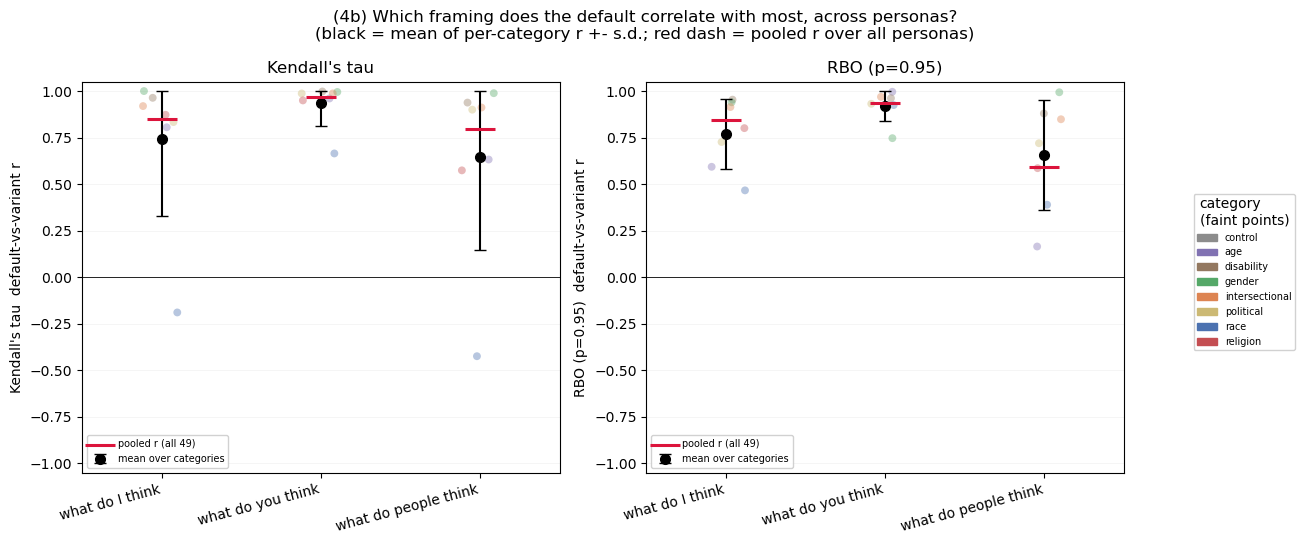

In [14]:
# (4b) summarize: mean of the per-category r's (equal weight per category, as in
# 4a) plus the POOLED r over all 49 personas for reference. Then visualize as in
# Figure 7 -- faint per-category r points with mean +- s.d. overlaid, and the
# pooled r marked in red.
summ = []
for col, label in FRAME_METRICS:
    for vt, vlab in VARIANTS:
        rs = frame_corr_percat[(frame_corr_percat['metric_col'] == col) &
                               (frame_corr_percat['variant'] == vlab)]['r'].dropna()
        mp = _paired(col, vt)
        pooled = stats.pearsonr(mp[f'{col}_def'], mp[f'{col}_var']).statistic
        summ.append({'metric': label, 'variant': vlab, 'n_categories': len(rs),
                     'mean_cat_r': rs.mean(), 'sd_across_cats': rs.std(), 'pooled_r': pooled})
frame_corr_summary = pd.DataFrame(summ)

print('(4b) default-vs-variant persona-shift correlation (across personas)')
display(
    frame_corr_summary.style
    .format({'mean_cat_r': '{:+.3f}', 'sd_across_cats': '{:.3f}', 'pooled_r': '{:+.3f}'})
    .hide(axis='index')
)
frame_corr_summary.to_csv(OUTPUT_DIR / 'figure_7b_framing_corr_summary.csv', index=False)

from matplotlib.patches import Patch
rng = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
xpos = np.arange(len(variant_labels))
for ax, (col, label) in zip(axes, FRAME_METRICS):
    sub_m = frame_corr_percat[frame_corr_percat['metric_col'] == col]
    for j, vlab in enumerate(variant_labels):
        s = sub_m[sub_m['variant'] == vlab].dropna(subset=['r'])
        jitter = rng.uniform(-0.12, 0.12, size=len(s))
        colors = [CAT_COLOR.get(c, '#333333') for c in s['category']]
        ax.scatter(np.full(len(s), j) + jitter, s['r'].to_numpy(), s=32, alpha=0.4,
                   color=colors, linewidths=0, zorder=1)
    means = np.array([sub_m[sub_m['variant'] == v]['r'].mean() for v in variant_labels])
    sds   = np.array([sub_m[sub_m['variant'] == v]['r'].std()  for v in variant_labels])
    # Pearson r is bounded to [-1, 1]; clip the +-s.d. whiskers to that range so
    # they don't render past the mathematically-possible limit. The raw s.d. is
    # large here because the per-category r's are noisy at n=3 (especially
    # Kendall's tau, which barely varies within a category) -- the faint points
    # show the true spread; this trims only the whisker, not the mean.
    yerr = np.vstack([np.minimum(sds, means + 1.0), np.minimum(sds, 1.0 - means)])
    ax.errorbar(xpos, means, yerr=yerr, fmt='o', color='black', ecolor='black',
                elinewidth=1.5, capsize=4, markersize=7, zorder=2, label='mean over categories')
    pooled = [frame_corr_summary[(frame_corr_summary['metric'] == label) &
              (frame_corr_summary['variant'] == v)]['pooled_r'].iloc[0] for v in variant_labels]
    ax.scatter(xpos, pooled, marker='_', s=450, color='crimson', linewidths=2.2,
               zorder=3, label='pooled r (all 49)')
    ax.axhline(0, color='black', linewidth=0.6)
    ax.set_xticks(xpos); ax.set_xticklabels(variant_labels, rotation=15, ha='right')
    ax.set_xlim(-0.5, len(variant_labels) - 0.5); ax.set_ylim(-1.05, 1.05)
    ax.set_ylabel(f'{label}  default-vs-variant r'); ax.set_title(label)
    ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=0.15, linewidth=0.6)
    ax.legend(fontsize=7, loc='lower left', framealpha=0.9)

fig.legend(handles=[Patch(color=CAT_COLOR.get(c, '#333333'), label=c) for c in frame_cats],
           fontsize=7, loc='center right', framealpha=0.9, title='category\n(faint points)')
fig.suptitle('(4b) Which framing does the default correlate with most, across personas?\n'
             '(black = mean of per-category r +- s.d.; red dash = pooled r over all personas)')
fig.tight_layout(rect=[0, 0, 0.88, 1])
fig.savefig(OUTPUT_DIR / f'figure_7b_framing_corr_summary_{BASELINE_TYPE}.png',
            dpi=300, bbox_inches='tight')
plt.show()

### (5) Extensions

Two follow-ups to (2) that the coarse correlation alone can't answer: **(5a)** whether the RM↔base-LM relationship depends on which baseline we compare against, and **(5b)** whether that relationship survives *within* persona categories or is largely a between-category effect.

#### (5a) Does the baseline choice change the RM↔base-LM relationship?

Section (2) reported the RM-vs-base-LM correlation for each baseline separately. Here we overlay both — `neutral` (bare "I am {persona}") and `control` ("I am a person who is {persona}") — on one scatter, each with its own fit and `r`, so we can see directly whether prefixing the baseline with "a person" changes how the RM's persona shift tracks the base LM's.

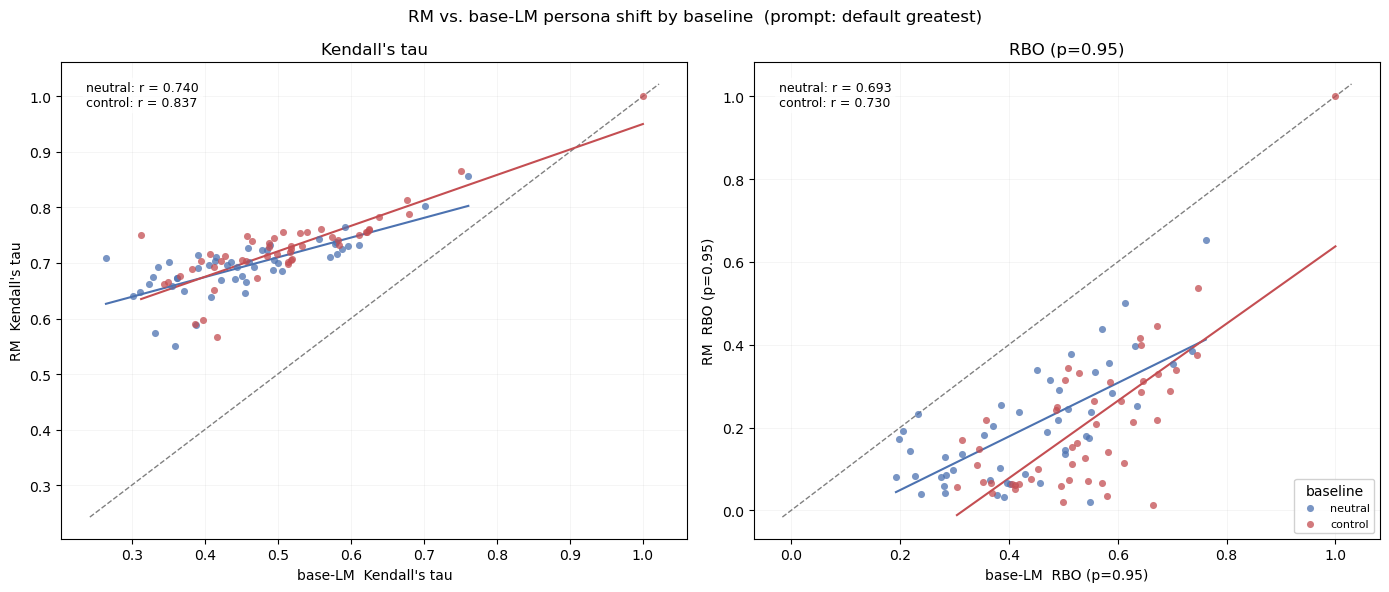

In [15]:
# FIGURE 8 (5a) -- does the RM<->base-LM relationship differ by baseline?
# Overlay the 'neutral' (default greatest) and 'control' (person-prefixed
# greatest) baselines on the same RM-vs-LM scatter for the selected TEMPLATE,
# each with its own fit line + Pearson r. Tight, overlapping clouds mean the
# choice of baseline barely changes how RM shift tracks base-LM shift.
c2b = pd.read_csv(ANALYSIS_DIR / 'summary_correlations.csv')
c2b = c2b[c2b['template'] == TEMPLATE].copy()
BASELINE_COLOR = {'neutral': '#4C72B0', 'control': '#C44E52'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (rm_col, lm_col, label) in zip(axes, METRIC_PAIRS):
    txt = []
    for baseline in ['neutral', 'control']:
        d = c2b[c2b['baseline_type'] == baseline]
        x, y = d[lm_col].to_numpy(), d[rm_col].to_numpy()
        ax.scatter(x, y, s=26, alpha=0.75, color=BASELINE_COLOR[baseline],
                   linewidths=0, label=baseline, zorder=3)
        slope, intercept = np.polyfit(x, y, 1); xs_line = np.array([x.min(), x.max()])
        ax.plot(xs_line, slope * xs_line + intercept, color=BASELINE_COLOR[baseline],
                linewidth=1.5, zorder=2)
        txt.append(f"{baseline}: r = {stats.pearsonr(x, y).statistic:.3f}")

    lo = min(c2b[lm_col].min(), c2b[rm_col].min())
    hi = max(c2b[lm_col].max(), c2b[rm_col].max()); pad = 0.03 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            color='gray', linestyle='--', linewidth=1, zorder=1)
    ax.text(0.04, 0.96, '\n'.join(txt), transform=ax.transAxes, va='top', ha='left',
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, linewidth=0))
    ax.set_xlabel(f'base-LM  {label}'); ax.set_ylabel(f'RM  {label}')
    ax.set_title(label); ax.set_axisbelow(True); ax.grid(True, alpha=0.15, linewidth=0.6)

axes[1].legend(fontsize=8, title='baseline', loc='lower right', framealpha=0.9)
fig.suptitle(f'RM vs. base-LM persona shift by baseline  (prompt: {PROMPT_TEMPLATE})')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f'figure_8_rm_vs_lm_by_baseline_{TEMPLATE}.png',
            dpi=300, bbox_inches='tight')
plt.show()

#### (5b) Does the RM↔base-LM relationship hold *within* categories?

The coarse `r` in (2) pools all 49 personas, so it can be inflated by *between-category* structure (e.g. political personas shift both models a lot, control personas shift both a little — that alone produces a positive correlation without any within-category link). Here we correlate RM vs base-LM persona-shift **inside each category**, and compare against two references: the pooled `r` (all personas) and the between-category `r` (correlating the 8 category means). If the between-category line sits above the pooled line, part of the headline correlation is a category-level effect rather than a persona-level one. *(Caveat: several categories have only 3 personas, so the per-category bars are noisy.)*

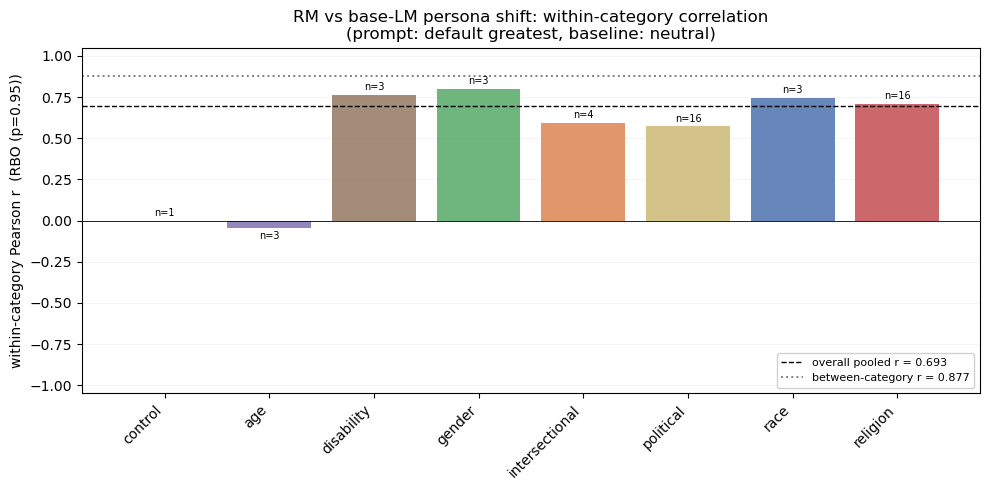

      category  n  within_r
       control  1       NaN
           age  3 -0.045917
    disability  3  0.765651
        gender  3  0.801461
intersectional  4  0.592681
     political 16  0.571485
          race  3  0.745717
      religion 16  0.709773

overall pooled r = 0.693 | between-category (category means) r = 0.877


In [16]:
# FIGURE 9 (5b) -- does the coarse RM<->base-LM correlation hold WITHIN persona
# categories, or is it inflated by between-category spread? Per category, we
# correlate RM vs base-LM persona-shift (RBO) across that category's personas.
# NOTE: several categories have only n=3 personas, so within-category r's are
# noisy -- read them as a sanity check, not precise effect sizes. The dashed
# line is the pooled r (all personas); the dotted line correlates the 8 category
# MEANS -- if between > pooled, the coarse relationship is partly a
# between-category effect.
d = c2b[c2b['baseline_type'] == BASELINE_TYPE].copy()
d['category'] = slugify(d['persona']).map(CATEGORY)
rm_col, lm_col, mlabel = METRIC_PAIRS[1]   # the RBO pair
wc_cats = sorted(d['category'].dropna().unique(), key=lambda c: (c != 'control', c))

rows = []
for cat in wc_cats:
    s = d[d['category'] == cat]
    ok = len(s) >= 3 and s[lm_col].std() > 0 and s[rm_col].std() > 0
    rows.append({'category': cat, 'n': len(s),
                 'within_r': stats.pearsonr(s[lm_col], s[rm_col]).statistic if ok else np.nan})
percat = pd.DataFrame(rows)

cm = d.groupby('category')[[lm_col, rm_col]].mean().reindex(wc_cats)
overall_r = stats.pearsonr(d[lm_col], d[rm_col]).statistic
between_r = stats.pearsonr(cm[lm_col], cm[rm_col]).statistic

fig, ax = plt.subplots(figsize=(10, 5))
xb = np.arange(len(percat))
ax.bar(xb, percat['within_r'].fillna(0),
       color=[CAT_COLOR.get(c, '#333333') for c in percat['category']], alpha=0.85)
for i, r in percat.iterrows():
    y = r['within_r'] if pd.notna(r['within_r']) else 0
    ax.annotate(f"n={r['n']}", (i, y), ha='center',
                va='bottom' if y >= 0 else 'top', fontsize=7,
                xytext=(0, 2 if y >= 0 else -2), textcoords='offset points')
ax.axhline(overall_r, color='black', linestyle='--', linewidth=1,
           label=f'overall pooled r = {overall_r:.3f}')
ax.axhline(between_r, color='gray', linestyle=':', linewidth=1.4,
           label=f'between-category r = {between_r:.3f}')
ax.axhline(0, color='black', linewidth=0.6)
ax.set_xticks(xb); ax.set_xticklabels(percat['category'], rotation=45, ha='right')
ax.set_ylabel(f'within-category Pearson r  ({mlabel})'); ax.set_ylim(-1.05, 1.05)
ax.set_title(f'RM vs base-LM persona shift: within-category correlation\n'
             f'(prompt: {PROMPT_TEMPLATE}, baseline: {BASELINE_TYPE})')
ax.legend(fontsize=8, loc='lower right', framealpha=0.9)
ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=0.15, linewidth=0.6)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f'figure_9_rm_lm_within_category_{TEMPLATE}_{BASELINE_TYPE}.png',
            dpi=300, bbox_inches='tight')
plt.show()

print(percat.to_string(index=False))
print(f'\noverall pooled r = {overall_r:.3f} | between-category (category means) r = {between_r:.3f}')